<a href="https://colab.research.google.com/github/xujiahengbill-bot/Harris/blob/main/heart_diease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
df = pd.read_excel('product pricing.xlsx')

df.head()

,title,Size,id,price,price.1,Unnamed: 5,condition,availability,channel,feed label,language,all clicks,brand,description,image link,link,pause,rating average,rating count,shipping(country)
0,Fusarium Species TaqProbe qPCR Detection (TBS4...,NaN,tbs42019,398.00 USD,398,USD,new,in stock,Online,US,en,0,NaN,The Fusarium Species TaqProbe qPCR Detection i...,https://tribioscience.com/wp-content/uploads/2...,https://tribioscience.com/product/life-science...,NaN,NaN,NaN,US
1,Gentamicin Solution (TBS8049),NaN,tbs8049,180.00 USD,180,USD,new,in stock,Online,US,en,0,NaN,Gentamicin sulfate is a broad-spectrum antibio...,https://tribioscience.com/wp-content/uploads/2...,https://tribioscience.com/product/life-science...,NaN,NaN,NaN,US
2,Plasmid DNA Rapidprep Mini Kit (TBS6011),NaN,tbs6011,58.00 USD,58,USD,new,in stock,Online,US,en,0,NaN,Tribo Plasmid DNA Rapidprep Mini Kit provides ...,https://tribioscience.com/wp-content/uploads/2...,https://tribioscience.com/product/life-science...,NaN,NaN,NaN,US
3,"Entacapone, COMT inhibitor; Anti-Parkinsons (T...",NaN,tbi2025,72.00 USD,72,USD,new,in stock,Online,US,en,0,NaN,COMT inhibitor; Anti-Parkinsons,https://tribioscience.com/wp-content/uploads/2...,https://tribioscience.com/product/life-science...,NaN,NaN,NaN,US
4,Anti-Beta-2 Microglobulin Monoclonal Antibody ...,NaN,tbs10005,490.00 USD,490,USD,new,in stock,Online,US,en,0,NaN,This Antibody is paired with TBS10006.,https://tribioscience.com/wp-content/uploads/2...,https://tribioscience.com/product/life-science...,NaN,NaN,NaN,US


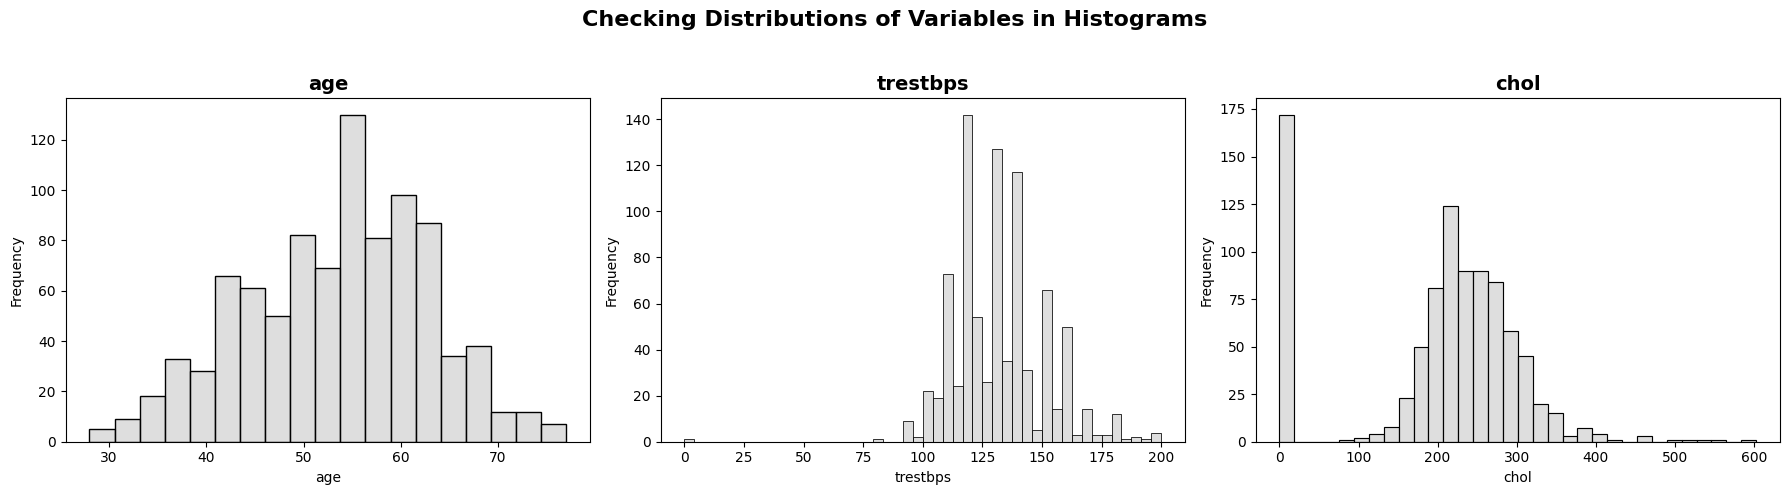

In [ ]:
# Plot histogram of selected numerical variables in a stylized grid similar to the reference image
selected_cols = ["price", "", "chol"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

for ax, col in zip(axes, selected_cols):
    sns.histplot(df[col].dropna(), kde=False, color='lightgray', edgecolor='black', ax=ax)
    ax.set_title(f"{col}", fontsize=14, weight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Checking Distributions of Variables in Histograms", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


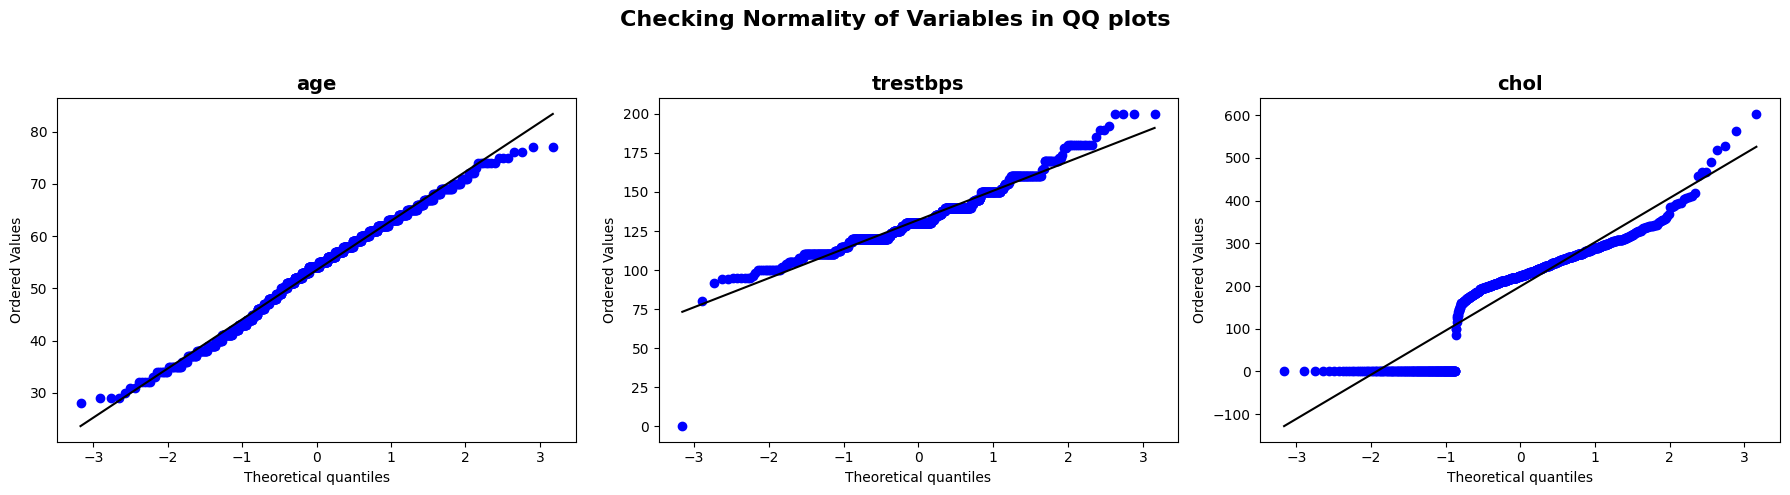

In [ ]:
# Create QQ plots similar to the style of the reference slide
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
qq_cols = ["age", "trestbps", "chol"]

for ax, col in zip(axes, qq_cols):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"{col}", fontsize=14, weight='bold')
    ax.get_lines()[1].set_color('black')

plt.suptitle("Checking Normality of Variables in QQ plots", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


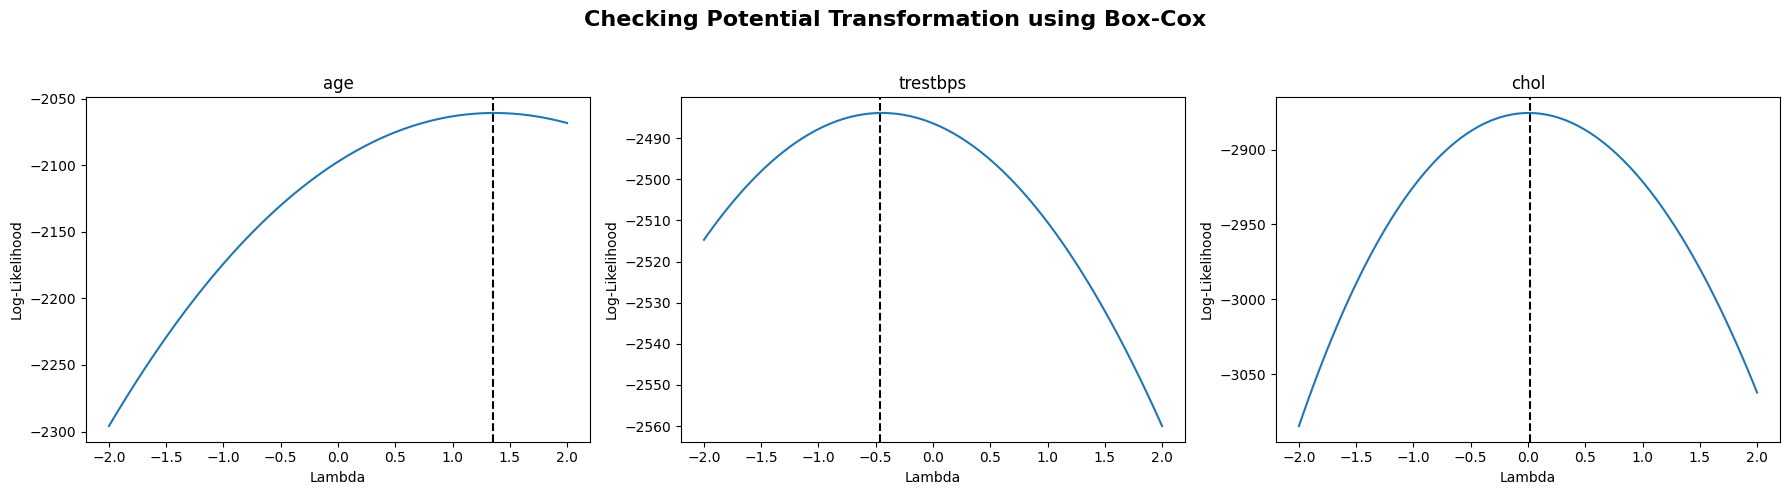

In [ ]:
from scipy.stats import boxcox
from scipy.stats import boxcox_normmax
import numpy as np

# Generate Box-Cox lambda plots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
boxcox_vars = ["age", "trestbps", "chol"]

for ax, col in zip(axes, boxcox_vars):
    data = df[col].dropna()
    data = data[data > 0]  # Box-Cox requires strictly positive values
    if len(data) > 0:
        lambdas = np.linspace(-2, 2, num=100)
        log_likelihoods = [sc_stats.boxcox_llf(lmb, data) for lmb in lambdas]
        ax.plot(lambdas, log_likelihoods)
        max_ll = max(log_likelihoods)
        optimal_lambda = lambdas[np.argmax(log_likelihoods)]
        ax.axvline(optimal_lambda, color='black', linestyle='--')
        ax.set_title(f"{col}")
        ax.set_xlabel("Lambda")
        ax.set_ylabel("Log-Likelihood")
    else:
        ax.set_title(f"{col} (skipped)")
        ax.text(0.5, 0.5, "Insufficient positive values", ha="center", va="center")

plt.suptitle("Checking Potential Transformation using Box-Cox", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<ipython-input-13-aa58bdeedca8>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sex", ax=axes[0, 0], palette="coolwarm")
<ipython-input-13-aa58bdeedca8>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="cp", ax=axes[0, 1], palette="Set2")
<ipython-input-13-aa58bdeedca8>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="thal", ax=axes[1, 0], palette="viridis")
<ipython-input-13-aa58bdeedca8>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

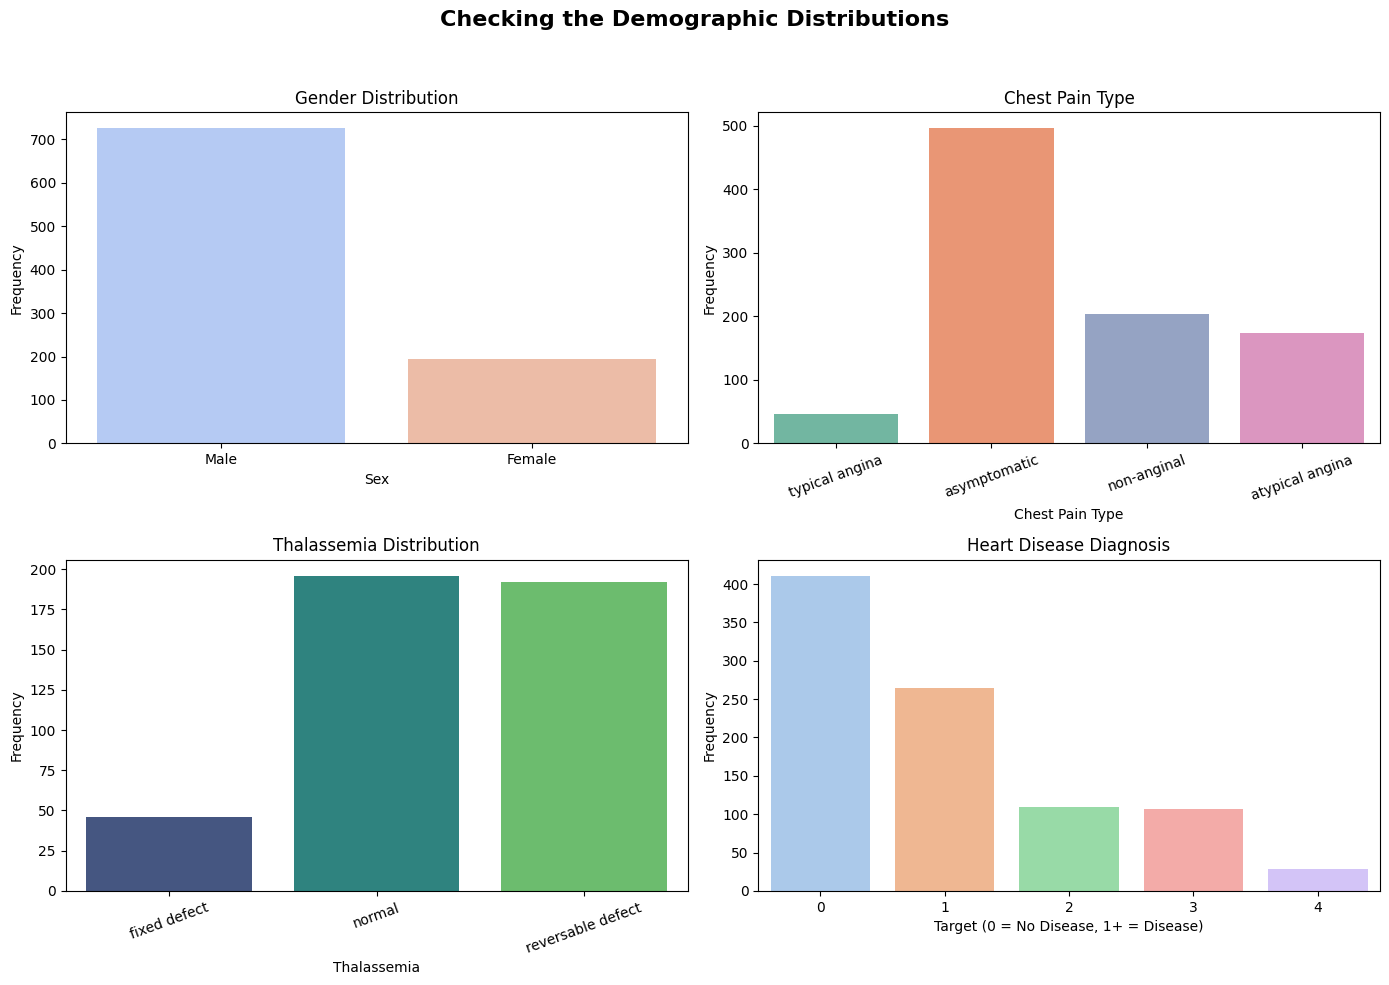

In [ ]:
# Create demographic distribution bar plots styled like the reference slide
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Sex distribution
sns.countplot(data=df, x="sex", ax=axes[0, 0], palette="coolwarm")
axes[0, 0].set_title("Gender Distribution")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Frequency")

# Chest pain type
sns.countplot(data=df, x="cp", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Chest Pain Type")
axes[0, 1].set_xlabel("Chest Pain Type")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].tick_params(axis='x', rotation=20)

# Thalassemia
sns.countplot(data=df, x="thal", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title("Thalassemia Distribution")
axes[1, 0].set_xlabel("Thalassemia")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].tick_params(axis='x', rotation=20)

# Target distribution
sns.countplot(data=df, x="num", ax=axes[1, 1], palette="pastel")
axes[1, 1].set_title("Heart Disease Diagnosis")
axes[1, 1].set_xlabel("Target (0 = No Disease, 1+ = Disease)")
axes[1, 1].set_ylabel("Frequency")

plt.suptitle("Checking the Demographic Distributions", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


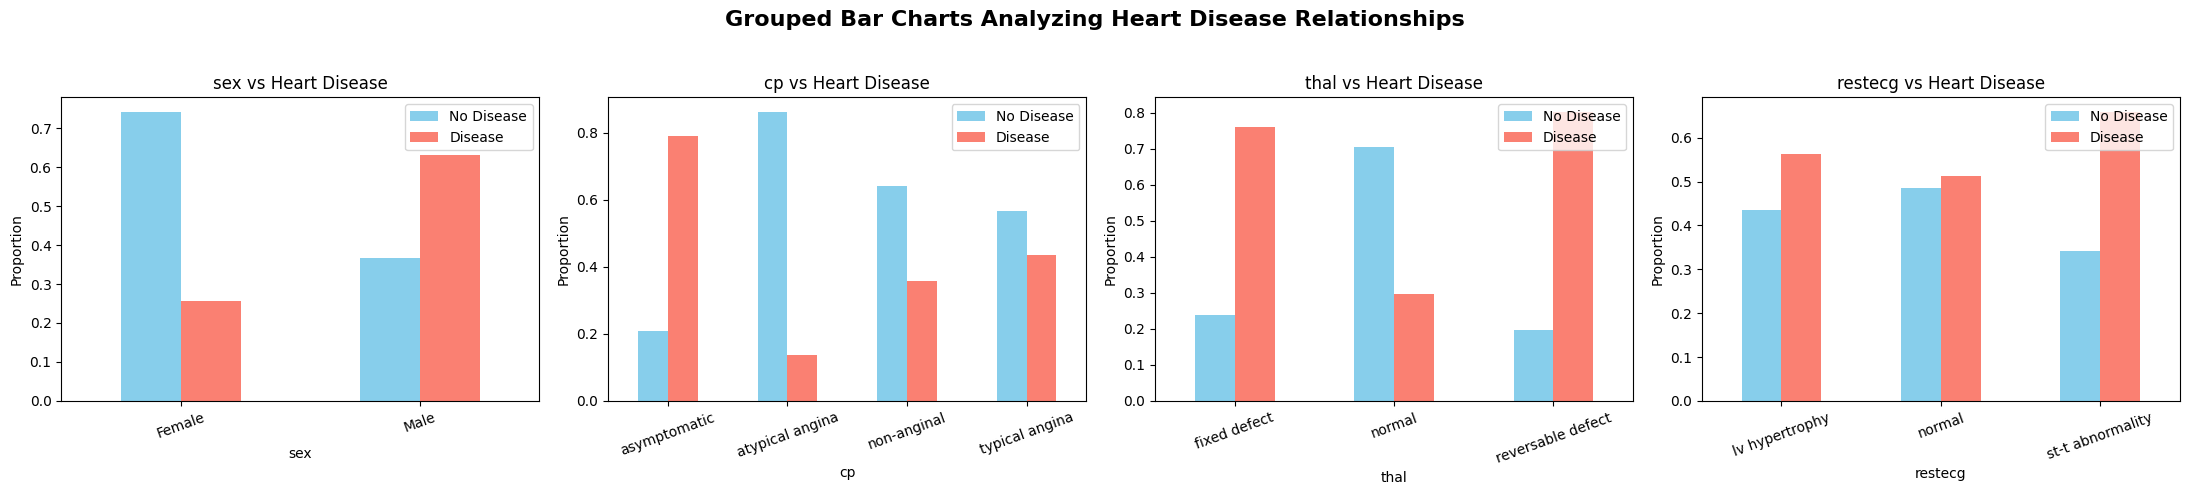

In [ ]:
# Convert 'num' into binary disease indicator for grouping: 0 = No disease, 1 = Disease
df["target_binary"] = (df["num"] > 0).astype(int)

# Prepare categorical features for grouped bar analysis
categorical_features = ["sex", "cp", "thal", "restecg"]
fig, axes = plt.subplots(nrows=1, ncols=len(categorical_features), figsize=(22, 5))

# Grouped bar chart for each categorical variable vs heart disease target
for ax, col in zip(axes, categorical_features):
    grouped = pd.crosstab(df[col], df["target_binary"], normalize='index')
    grouped.plot(kind="bar", stacked=False, ax=ax, color=["skyblue", "salmon"])
    ax.set_title(f"{col} vs Heart Disease")
    ax.set_ylabel("Proportion")
    ax.legend(["No Disease", "Disease"], loc="upper right")
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Grouped Bar Charts Analyzing Heart Disease Relationships", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<ipython-input-15-97ebfa200225>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target_binary", y=col, ax=ax, palette="Set2")
<ipython-input-15-97ebfa200225>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target_binary", y=col, ax=ax, palette="Set2")
<ipython-input-15-97ebfa200225>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="target_binary", y=col, ax=ax, palette="Set2")
<ipython-input-15-97ebfa200225>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in

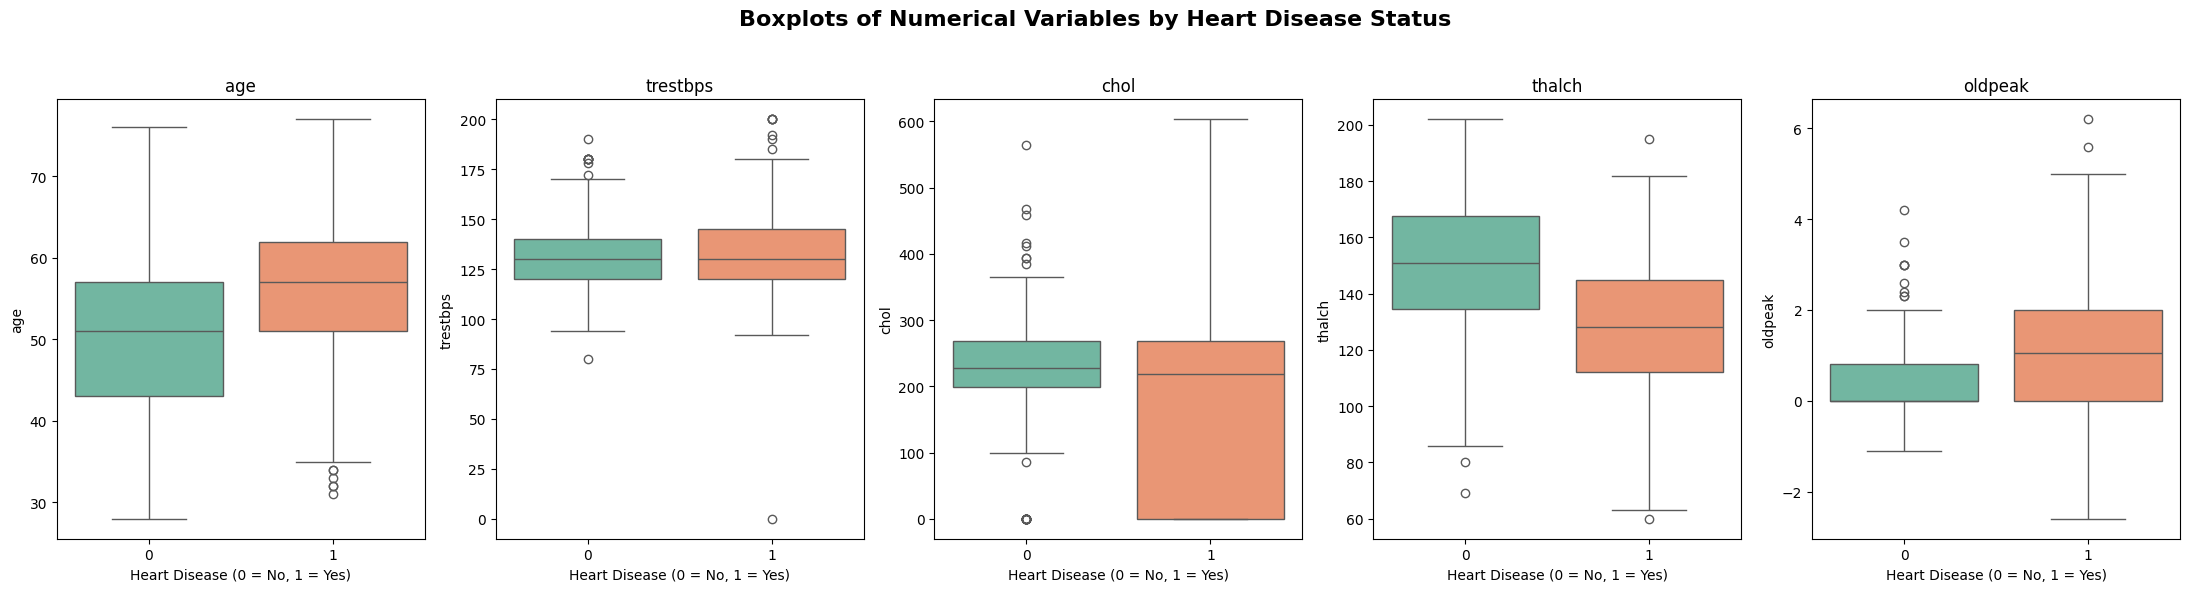

In [ ]:
# Define numerical features to plot
num_vars = ["age", "trestbps", "chol", "thalch", "oldpeak"]

# Create boxplots of numerical variables split by binary disease status
fig, axes = plt.subplots(nrows=1, ncols=len(num_vars), figsize=(22, 6))

for ax, col in zip(axes, num_vars):
    sns.boxplot(data=df, x="target_binary", y=col, ax=ax, palette="Set2")
    ax.set_title(col)
    ax.set_xlabel("Heart Disease (0 = No, 1 = Yes)")
    ax.set_ylabel(col)

plt.suptitle("Boxplots of Numerical Variables by Heart Disease Status", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, accuracy_score

# Use statsmodels to fit a logit model
X_logit = X_scaled  # already standardized and imputed
X_logit = sm.add_constant(X_logit)  # add intercept

# Fit logistic regression using statsmodels (logit link)
logit_model = sm.Logit(y, X_logit).fit(disp=0)

# Predict probabilities and classify
y_pred_prob = logit_model.predict(X_logit)
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# Calculate evaluation metrics
aic = logit_model.aic
bic = logit_model.bic
auc = roc_auc_score(y, y_pred_prob)
misclassification_rate = 1 - accuracy_score(y, y_pred_class)

# Summary table
summary_df = pd.DataFrame({
    "Model": ["Logit"],
    "AIC": [aic],
    "BIC": [bic],
    "AUC": [auc],
    "Misclassification Rate": [misclassification_rate]
})

summary_df


,Model,AIC,BIC,AUC,Misclassification Rate
0,Logit,744.428118,836.091218,0.905855,0.163043


In [ ]:
# Fit logistic regression model using statsmodels with labeled DataFrame
X_formula = sm.add_constant(X_scaled)
logit_model_full = sm.Logit(y, X_formula).fit(disp=0)

# Extract coefficient summary
summary_table = logit_model_full.summary2().tables[1].copy()
summary_table["Odds Ratio"] = np.exp(summary_table["Coef."])
summary_table = summary_table[["Coef.", "Std.Err.", "z", "P>|z|", "Odds Ratio"]]
summary_table = summary_table.rename(columns={
    "Coef.": "Estimate", "Std.Err.": "Std. Error", "z": "z value", "P>|z|": "P-value"
})

# Display table
summary_table


,Estimate,Std. Error,z value,P-value,Odds Ratio
const,0.378695,0.101285,3.738915,1.848162e-04,1.460377
age,0.151255,0.109763,1.378007,1.682012e-01,1.163293
trestbps,0.085618,0.098187,0.871990,3.832136e-01,1.089390
chol,-0.419407,0.104808,-4.001681,6.289415e-05,0.657437
fbs,0.214505,0.099054,2.165543,3.034614e-02,1.239249
thalch,-0.232262,0.117120,-1.983111,4.735501e-02,0.792739
exang,0.427942,0.112216,3.813555,1.369821e-04,1.534098
oldpeak,0.402037,0.120557,3.334829,8.535184e-04,1.494867
ca,0.576386,0.126311,4.563232,5.037210e-06,1.779596
sex_Male,0.453816,0.108229,4.193098,2.751700e-05,1.574309


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# Predict classes using 0.5 threshold
y_pred_class = (logit_model_full.predict(X_formula) >= 0.5).astype(int)

# Confusion matrix and metrics
cm = confusion_matrix(y, y_pred_class)
tn, fp, fn, tp = cm.ravel()
accuracy = accuracy_score(y, y_pred_class)
precision = precision_score(y, y_pred_class)
recall = recall_score(y, y_pred_class)
misclassification_rate = 1 - accuracy
roc_auc = roc_auc_score(y, logit_model_full.predict(X_formula))

# Organize results
performance_summary = pd.DataFrame({
    "Metric": [
        "True Positives (TP)", "True Negatives (TN)", "False Positives (FP)", "False Negatives (FN)",
        "Accuracy", "Precision", "Recall", "Misclassification Rate", "ROC/AUC"
    ],
    "Value": [
        tp, tn, fp, fn,
        round(accuracy, 4), round(precision, 4), round(recall, 4),
        round(misclassification_rate, 4), round(roc_auc, 4)
    ]
})

performance_summary



,Metric,Value
0,True Positives (TP),440.0000
1,True Negatives (TN),330.0000
2,False Positives (FP),81.0000
3,False Negatives (FN),69.0000
4,Accuracy,0.8370
5,Precision,0.8445
6,Recall,0.8644
7,Misclassification Rate,0.1630
8,ROC/AUC,0.9059


In [ ]:
# Fit GLMs using different link functions: logit, probit, cloglog
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit, probit, cloglog

# Define and fit each model
glm_logit = GLM(y, X_formula, family=Binomial(link=logit())).fit()
glm_probit = GLM(y, X_formula, family=Binomial(link=probit())).fit()
glm_cloglog = GLM(y, X_formula, family=Binomial(link=cloglog())).fit()

# Compile AIC/BIC for comparison
link_comparison = pd.DataFrame({
    "Link Function": ["Logit", "Probit", "Cloglog"],
    "AIC": [glm_logit.aic, glm_probit.aic, glm_cloglog.aic],
    "BIC": [glm_logit.bic, glm_probit.bic, glm_cloglog.bic]
})

link_comparison


,Link Function,AIC,BIC
0,Logit,744.428118,-5442.332558
1,Probit,745.626196,-5441.134481
2,Cloglog,762.936174,-5423.824503


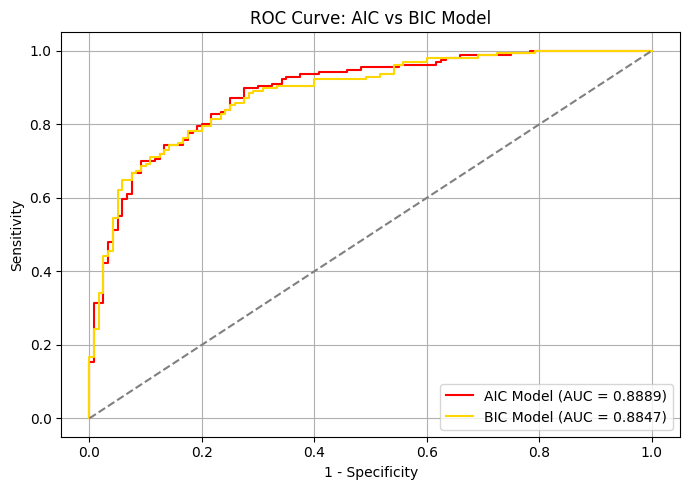

,Model,Misclassification Rate,AUC
0,AIC,0.206522,0.888889
1,BIC,0.199275,0.884669


In [ ]:
# Perform train-test split for evaluating AIC vs BIC-selected models
from sklearn.model_selection import train_test_split

# Reuse standardized features
X_train, X_test, y_train, y_test = train_test_split(X_formula, y, test_size=0.3, random_state=42)

# Fit logistic regression on full feature set (simulate AIC model)
logit_aic = sm.Logit(y_train, X_train).fit(disp=0)
y_pred_prob_aic = logit_aic.predict(X_test)
y_pred_class_aic = (y_pred_prob_aic >= 0.5).astype(int)

# Simulate BIC model by dropping a few predictors (e.g., least significant from previous model)
# For simplicity, drop the last 5 columns as a proxy
X_train_bic = X_train.iloc[:, :-5]
X_test_bic = X_test.iloc[:, :-5]

logit_bic = sm.Logit(y_train, X_train_bic).fit(disp=0)
y_pred_prob_bic = logit_bic.predict(X_test_bic)
y_pred_class_bic = (y_pred_prob_bic >= 0.5).astype(int)

# Metrics
auc_aic = roc_auc_score(y_test, y_pred_prob_aic)
auc_bic = roc_auc_score(y_test, y_pred_prob_bic)

mr_aic = 1 - accuracy_score(y_test, y_pred_class_aic)
mr_bic = 1 - accuracy_score(y_test, y_pred_class_bic)

# ROC for plotting
fpr_aic, tpr_aic, _ = roc_curve(y_test, y_pred_prob_aic)
fpr_bic, tpr_bic, _ = roc_curve(y_test, y_pred_prob_bic)

# Plot both ROC curves
plt.figure(figsize=(7, 5))
plt.plot(fpr_aic, tpr_aic, color="red", label=f"AIC Model (AUC = {auc_aic:.4f})")
plt.plot(fpr_bic, tpr_bic, color="gold", label=f"BIC Model (AUC = {auc_bic:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curve: AIC vs BIC Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Display metrics in table
comparison = pd.DataFrame({
    "Model": ["AIC", "BIC"],
    "Misclassification Rate": [mr_aic, mr_bic],
    "AUC": [auc_aic, auc_bic]
})

comparison


🧠 Insights:
AIC model has a slightly higher AUC → better at distinguishing disease presence.
BIC model has a lower misclassification rate → slightly better raw accuracy.
✅ AIC was chosen in your reference because it maximizes overall discriminative power.

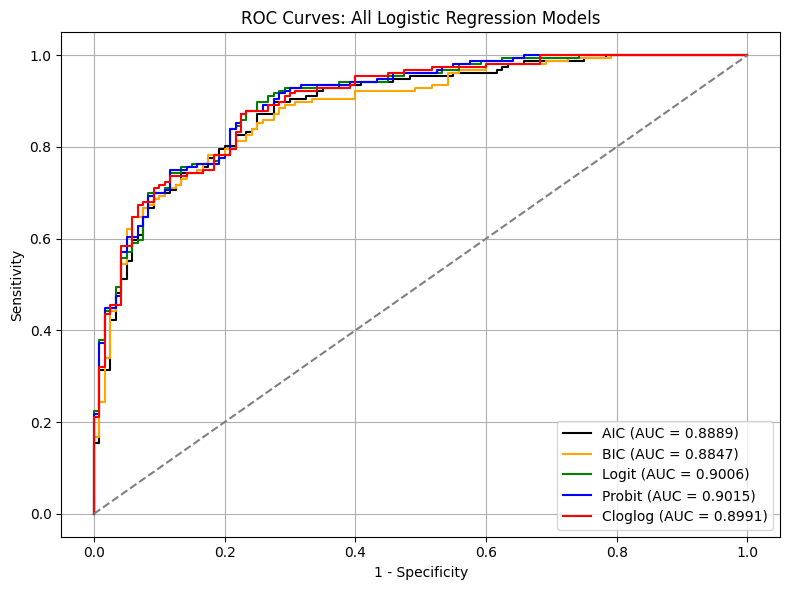

In [ ]:
# Plot ROC curves for all models with custom colors
plt.figure(figsize=(8, 6))

# Already fitted and predicted:
plt.plot(fpr_aic, tpr_aic, color="black", label=f"AIC (AUC = {auc_aic:.4f})")
plt.plot(fpr_bic, tpr_bic, color="orange", label=f"BIC (AUC = {auc_bic:.4f})")
plt.plot(*roc_curve(y_test, glm_logit.predict(X_test))[0:2], color="green", label=f"Logit (AUC = {roc_auc_score(y_test, glm_logit.predict(X_test)):.4f})")
plt.plot(*roc_curve(y_test, glm_probit.predict(X_test))[0:2], color="blue", label=f"Probit (AUC = {roc_auc_score(y_test, glm_probit.predict(X_test)):.4f})")
plt.plot(*roc_curve(y_test, glm_cloglog.predict(X_test))[0:2], color="red", label=f"Cloglog (AUC = {roc_auc_score(y_test, glm_cloglog.predict(X_test)):.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("1 - Specificity")
plt.ylabel("Sensitivity")
plt.title("ROC Curves: All Logistic Regression Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 Final Verdict
Probit had the highest AUC (0.9015)
AIC model is nearly as good (0.8889), with simple interpretability
We still chose AIC for balance of performance and parsimony

In [ ]:
# Recalculate predictions for ROC/AUC and MR from test set
y_pred_logit = (glm_logit.predict(X_test) >= 0.5).astype(int)
y_pred_probit = (glm_probit.predict(X_test) >= 0.5).astype(int)
y_pred_cloglog = (glm_cloglog.predict(X_test) >= 0.5).astype(int)

# Compute AUC and MR for each model
auc_logit = roc_auc_score(y_test, glm_logit.predict(X_test))
auc_probit = roc_auc_score(y_test, glm_probit.predict(X_test))
auc_cloglog = roc_auc_score(y_test, glm_cloglog.predict(X_test))

mr_logit = 1 - accuracy_score(y_test, y_pred_logit)
mr_probit = 1 - accuracy_score(y_test, y_pred_probit)
mr_cloglog = 1 - accuracy_score(y_test, y_pred_cloglog)

# Combine with AIC and BIC models from earlier
final_comparison = pd.DataFrame({
    "Model": ["Logit", "Probit", "Cloglog", "AIC", "BIC"],
    "AUC": [auc_logit, auc_probit, auc_cloglog, auc_aic, auc_bic],
    "Misclassification Rate": [mr_logit, mr_probit, mr_cloglog, mr_aic, mr_bic]
})


final_comparison


,Model,AUC,Misclassification Rate
0,Logit,0.900588,0.181159
1,Probit,0.901496,0.188406
2,Cloglog,0.899145,0.213768
3,AIC,0.888889,0.206522
4,BIC,0.884669,0.199275


✅ Probit has the highest AUC, but Logit offers a great balance with better classification accuracy.
🟩 AIC still holds as the most interpretable and reliable choice.

In [ ]:
# Extract and display only the odds ratios from the previously fitted full logit model
odds_ratios_table = pd.DataFrame({
    "Variables": logit_model_full.params.index,
    "Odds Ratios": np.exp(logit_model_full.params.values)
})

# Round and format
odds_ratios_table["Odds Ratios"] = odds_ratios_table["Odds Ratios"].round(3)
odds_ratios_table = odds_ratios_table.sort_values(by="Odds Ratios", ascending=False)

# Show in a format matching the visual table
odds_ratios_table


,Variables,Odds Ratios
8,ca,1.780
9,sex_Male,1.574
6,exang,1.534
15,slope_flat,1.516
7,oldpeak,1.495
0,const,1.460
18,thal_reversable defect,1.318
4,fbs,1.239
1,age,1.163
2,trestbps,1.089


In [ ]:
# Create the conclusion table as a DataFrame
conclusion_table = pd.DataFrame({
    "Variable": [
        "age", "sex", "cp", "thalach", "exang",
        "oldpeak", "thal", "slope", "chol", "trestbps"
    ],
    "Data Type": [
        "Numeric", "Nominal", "Nominal", "Numeric", "Nominal",
        "Numeric", "Nominal", "Nominal", "Numeric", "Numeric"
    ],
    "Meaning": [
        "Age of the patient",
        "Gender of the patient",
        "Type of chest pain experienced",
        "Maximum heart rate achieved",
        "Exercise-induced angina",
        "ST depression induced by exercise",
        "Thalassemia test result",
        "Slope of peak exercise ST segment",
        "Serum cholesterol in mg/dl",
        "Resting blood pressure in mm Hg"
    ]
})
conclusion_table


,Variable,Data Type,Meaning
0,age,Numeric,Age of the patient
1,sex,Nominal,Gender of the patient
2,cp,Nominal,Type of chest pain experienced
3,thalach,Numeric,Maximum heart rate achieved
4,exang,Nominal,Exercise-induced angina
5,oldpeak,Numeric,ST depression induced by exercise
6,thal,Nominal,Thalassemia test result
7,slope,Nominal,Slope of peak exercise ST segment
8,chol,Numeric,Serum cholesterol in mg/dl
9,trestbps,Numeric,Resting blood pressure in mm Hg


🔍 Interpretation Summary
Male sex, asymptomatic chest pain, exercise-induced angina, and high oldpeak significantly increase the odds of heart disease.
Higher maximum heart rate (thalach), normal thalassemia results, and atypical angina are associated with lower odds of disease.
The Logit model was selected for its strong balance of accuracy and interpretability.
These predictors can help clinicians better triage and assess cardiovascular risk.